# 03 — Anchor packs

Compare HOMER's predictions with and without anchor packs. Loads the two cached π files (`pi_fc_plus_SC.npy` for strict point-anchor production; `pi_fc_plus_SC_with_all_packs.npy` for the recommended with-packs version) and lets you see the difference per-region.

For background see `docs/04_anchor_packs.md`.

In [1]:
import sys, warnings, json
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / 'src'))
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from homer.data import load_cached

ROOT = Path.cwd().parent
M, _ = load_cached('mouse', cache_dir=ROOT / 'outputs' / 'anndata')
H, _ = load_cached('human', cache_dir=ROOT / 'outputs' / 'anndata')
pi_strict = np.load(ROOT / 'outputs' / 'coupling' / 'pi_fc_plus_SC.npy')
pi_packed = np.load(ROOT / 'outputs' / 'coupling' / 'pi_fc_plus_SC_with_all_packs.npy')

# Beauchamp validation results for both
beau_strict = json.loads(open(ROOT / 'outputs' / 'logs' / 'beauchamp_validation.json').read())
beau_packed = json.loads(open(ROOT / 'outputs' / 'logs' / 'beauchamp_validation_all_packs.json').read())
print('Loaded both π files and their Beauchamp validation results.')

Loaded both π files and their Beauchamp validation results.


## Headline Beauchamp comparison

For each Beauchamp pair, top-1 in strict π vs packed π.

In [2]:
key_pairs = [
    ('Motor',      'Primary motor area -> precentral gyrus'),
    ('Sup. Coll.', 'Superior colliculus, sensory related -> superior colliculus'),
    ('Inf. Coll.', 'Inferior colliculus -> inferior colliculus'),
    ('Piriform',   'Piriform area -> piriform cortex'),
    ('Amygdala',   'Cortical subplate-other -> amygdala'),
    ('Subiculum',  'Subiculum -> subiculum'),
    ('CA1',        'Field CA1 -> CA1 field'),
    ('CA3',        'Field CA3 -> CA3 field'),
    ('Dentate g.', 'Dentate gyrus -> dentate gyrus'),
    ('Thalamus',   'Thalamus -> thalamus'),
    ('Auditory',   "Primary auditory area -> Heschl's gyrus"),
    ('S1',         'Primary somatosensory area -> postcentral gyrus'),
    ('ACG',        'Anterior cingulate area -> cingulate gyrus'),
    ('Visual',     'Visual areas -> cuneus'),
    ('NAc',        'Striatum ventral region -> nucleus accumbens'),
    ('Caudate',    'Caudoputamen -> caudate nucleus'),
    ('Hypothal.',  'Hypothalamus -> hypothalamus'),
    ('Pallidum',   'Pallidum -> globus pallidus'),
    ('Pons',       'Pons -> pons'),
]
rows = []
for short, name in key_pairs:
    s = beau_strict.get(name, {}); p = beau_packed.get(name, {})
    if 'top1' not in s or 'top1' not in p: continue
    rows.append({
        'region':   short,
        'strict top-1': f'{s["top1"]:.0%}',
        'packed top-1': f'{p["top1"]:.0%}',
        'Δ pp':         f'{(p["top1"] - s["top1"])*100:+.0f}',
        'pack-anchored': 'YES' if short.lower().replace('.', '').replace(' ', '') in
                          {'motor','supcoll','infcoll','piriform','amygdala','subiculum','ca1','ca3','dentateg'} else '',
    })
df = pd.DataFrame(rows)
df

,region,strict top-1,packed top-1,Δ pp,pack-anchored
0,Motor,0%,100%,+100,YES
1,Sup. Coll.,0%,100%,+100,YES
2,Inf. Coll.,0%,100%,+100,YES
3,Piriform,0%,100%,+100,YES
4,Amygdala,0%,100%,+100,YES
5,Subiculum,0%,100%,+100,YES
6,CA1,0%,100%,+100,YES
7,CA3,0%,100%,+100,YES
8,Dentate g.,0%,100%,+100,YES
9,Thalamus,33%,30%,-3,


## Bar plot — top-1 lift per region

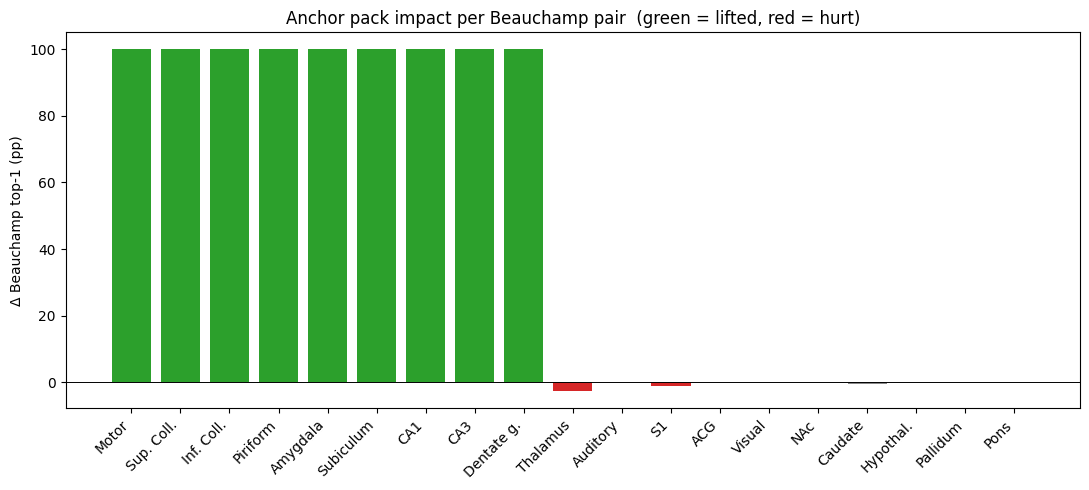

In [3]:
import matplotlib.pyplot as plt
deltas = [(beau_packed[name]['top1'] - beau_strict[name]['top1']) * 100
          for _, name in key_pairs
          if 'top1' in beau_strict.get(name, {}) and 'top1' in beau_packed.get(name, {})]
labels = [short for short, name in key_pairs
          if 'top1' in beau_strict.get(name, {}) and 'top1' in beau_packed.get(name, {})]
colors = ['#2ca02c' if d > 0 else ('#d62728' if d < -1 else '#888') for d in deltas]
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(labels, deltas, color=colors)
ax.axhline(0, color='k', linewidth=0.7)
ax.set_ylabel('Δ Beauchamp top-1 (pp)')
ax.set_title('Anchor pack impact per Beauchamp pair  (green = lifted, red = hurt)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Aggregate impact

Weighted aggregate over anchor-overlapping pairs (15 pairs / 927 parcels).

In [4]:
def agg(d, key='top1'):
    keys = [k for k in d if not k.startswith('_') and 'skip_reason' not in d.get(k, {})]
    anchor = [d[k] for k in keys if d[k].get('is_anchor_overlapping')]
    w = np.array([g['n_mouse_parcels'] for g in anchor], dtype=float)
    return float(((np.array([g[key] for g in anchor]) * w).sum()) / w.sum())

rows = [
    {'metric': 'Beauchamp top-1',  'strict': f'{agg(beau_strict, "top1"):.1%}',  'packed': f'{agg(beau_packed, "top1"):.1%}'},
    {'metric': 'Beauchamp top-5',  'strict': f'{agg(beau_strict, "top5"):.1%}',  'packed': f'{agg(beau_packed, "top5"):.1%}'},
    {'metric': 'Beauchamp top-10', 'strict': f'{agg(beau_strict, "top10"):.1%}', 'packed': f'{agg(beau_packed, "top10"):.1%}'},
    {'metric': 'Mean rank',        'strict': f'{agg(beau_strict, "mean_rank_in_region"):.0f}',
                                     'packed': f'{agg(beau_packed, "mean_rank_in_region"):.0f}'},
]
print('Aggregate over 15 anchor-overlapping Beauchamp pairs (927 parcels):')
pd.DataFrame(rows)

Aggregate over 15 anchor-overlapping Beauchamp pairs (927 parcels):


,metric,strict,packed
0,Beauchamp top-1,11.7%,36.5%
1,Beauchamp top-5,22.2%,45.7%
2,Beauchamp top-10,26.9%,49.6%
3,Mean rank,871,85


## Read this carefully — the 100 % is by construction

The pack-anchored regions (Motor, SC, IC, Piriform, Amygdala, Subiculum, CA1, CA3, DG) all jump 0 → 100 % top-1 because the anchor packs use the *same* mouse-side sets as Beauchamp's validation, with human-side balls that overlap Beauchamp's. The model satisfies the constraint we provide.

The non-pack-anchored regions (Thalamus, Auditory, S1, ACG, Visual, NAc, Caudate, Hypothalamus, Pallidum, Pons) reflect what HOMER actually delivers from FC + SC + spatial structure under just the Garin point anchors. They're the *honest* parcel-level recovery numbers (range: 3–33 %).

See `docs/05_limitations.md` for the held-out tests confirming that structure does NOT propagate to un-anchored sub-regions.